In [434]:
#DEFINE PROBLEM
# The goal of this project is to analyze e-commerce transaction data
# and understand customer behavior, product performance, and sales patterns.
# We also aim to predict total sales using machine learning.

In [435]:
#DATA COLLECTION
# Data was collected from Kaggle (Online Retail Dataset)
# This dataset contains real-world e-commerce transactions

In [436]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



%matplotlib inline

In [437]:


import pandas as pd
#reading data from the file
df = pd.read_csv("online_retail.csv.csv", encoding='latin1')

#show data to helps us understand the structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [438]:
 #show fitsr 5 rows before cleaning
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [439]:
#gives summary statistics like mean, min, max
df.describe()

#show how many missing values exis in each column
df.isnull().sum()

#DATA CLEANING

#delet missing value
df = df.dropna(subset=['CustomerID', 'Description'])

# Check duplicated rows before removing them
print("Duplicates:", df.duplicated().sum())

#delet duplicates
df = df.drop_duplicates()

#remove invalid data
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

#convert invoicedata to proper data format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#convert customerID to integer for consistency
df['CustomerID'] = df['CustomerID'].astype(int)

#calculate total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Duplicates: 0


In [440]:
# Check the new shape after cleaning
print("Shape after cleaning:", df.shape)

# Check if missing values still exist
print(df.isnull().sum())

# Show first 5 rows after cleaning
df.head()

Shape after cleaning: (397884, 10)
index          0
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [441]:
#EDA:

In [442]:
# Top selling products
# This shows which products were sold the most
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [443]:
# Total sales
# This calculates total revenue
total_sales = df['TotalPrice'].sum()
print("Total Sales:", total_sales)

Total Sales: 8911407.904


In [444]:
# Sales by country
# This shows which countries generate the most revenue
sales_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(sales_country)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


In [445]:
# Top customers
# This shows customers who spent the most money
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: TotalPrice, dtype: float64


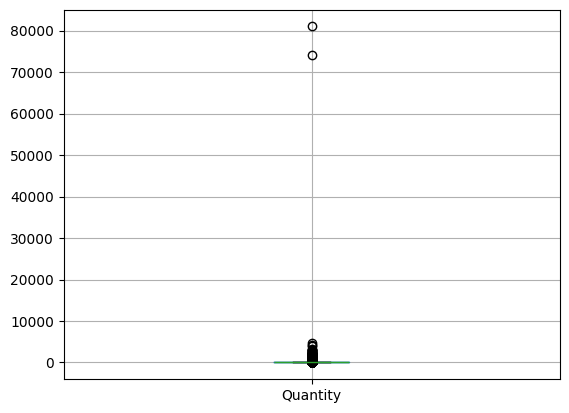

In [446]:
# Detect outliers using boxplot
df.boxplot(column=['Quantity'])
plt.show()

In [447]:
#Preparing data for machine learning

In [448]:
# Convert categorical data into numbers
# Machine learning models need numbers, not text
df_ml = pd.get_dummies(df, columns=['Country'])

In [449]:
# Create date features from InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

# Create customer total spending
customer_total = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_total.columns = ['CustomerID', 'CustomerTotal']
df = df.merge(customer_total, on='CustomerID', how='left')

# Create number of orders per customer
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'OrderCount']
df = df.merge(customer_orders, on='CustomerID', how='left')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Features created successfully")
print(df.columns)

Features created successfully
Index(['index', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice',
       'Year', 'Month', 'Day', 'Hour', 'CustomerTotal', 'OrderCount'],
      dtype='object')


In [450]:
# Select features and target
# X = input data, y = output we want to predict
X = df[[
    'Quantity',
    'UnitPrice',
    'Year',
    'Month',
    'Day',
    'Hour',
    'CustomerTotal',
    'OrderCount'
]]
y = df['TotalPrice']

In [451]:
# Customer total spend
customer_total = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_total.columns = ['CustomerID', 'CustomerTotal']
df = df.merge(customer_total, on='CustomerID', how='left')

# Number of orders per customer
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'OrderCount']
df = df.merge(customer_orders, on='CustomerID', how='left')

In [452]:
# Split the data
# We split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [453]:
# Train model
# We train a simple Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [454]:
#MODEL EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", model.score(X_test, y_test))
# This shows how good the model is
score = model.score(X_test, y_test)
print("Model Accuracy:", score)

MAE: 13.906343400258704
MSE: 111323.37019492303
R2 Score: 0.7083304852082681
Model Accuracy: 0.7083304852082681


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

# --- 1. Prepare Features (X) and Target (y) ---
# We drop non-numeric columns and columns we don't need for prediction.
# 'Country' is already handled by get_dummies in previous steps.
cols_to_drop = ['TotalPrice', 'InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'index']
X = df_ml.drop(columns=[col for col in cols_to_drop if col in df_ml.columns])
y = df_ml['TotalPrice']

# --- 2. Split Data into Training (80%) and Testing (20%) ---
# This ensures we evaluate the model on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Build and Train Linear Regression Model ---
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


# --- 4. Evaluate the Model Performance ---
# We use the R-squared score to check the accuracy percentage.
score = model.score(X_test, y_test)
print(f"Improved Model Accuracy: {score * 100:.2f}%")

# --- 5. Prediction Test (Actual vs Predicted) ---
# Testing the model on the first 5 rows of the test set to see the variance.
predictions = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test[:5], 'Predicted': predictions[:5]})
print("\n--- Comparison (Actual vs Predicted) ---")
print(comparison)

In [ ]:
import datetime as dt

# Ensure InvoiceDate is in datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# --- 1. Define a reference date ---
# We take the day after the last invoice in the dataset as our snapshot date
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# --- 2. Calculate RFM Metrics for each customer ---
# Recency: Days since last purchase
# Frequency: Number of invoices
# Monetary: Total spend
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

# --- 3. Rename columns for clarity ---
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# --- 4. Filtering Outliers ---
# To make the clustering more accurate, we keep typical customers (ignoring extreme outliers)
rfm = rfm[(rfm['Monetary'] > 0) & (rfm['Monetary'] < 10000)]
rfm = rfm[rfm['Frequency'] < 1000]

print("RFM Analysis Table (First 5 Rows):")
print(rfm.head())

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 1. Scaling the data ---
# K-Means is sensitive to the scale of data, so we must standardize it
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# --- 2. Applying K-Means ---
# Let's start by dividing them into 4 logical groups
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# --- 3. View the results ---
print("\nCustomer Segments Assigned:")
print(rfm.groupby('Cluster').mean())

In [ ]:
#VISUALIZATION

In [ ]:
# Plot top countries by sales
# This creates a bar chart for easy visualization
sales_country.plot(kind='bar')

plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
#  Visualization of Customer Segments
plt.figure(figsize=(10, 6))

# Plotting Frequency vs Monetary to see the segments
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis', s=100)

plt.title('Customer Segments: Frequency vs Monetary', fontsize=15)
plt.xlabel('Frequency (How often they buy)', fontsize=12)
plt.ylabel('Monetary (How much they spend)', fontsize=12)
plt.legend(title='Cluster')
plt.show()

In [ ]:
top_products.plot(kind='bar', figsize=(12, 6))

plt.title('Top 10 Selling Products by Quantity', fontsize=15)
plt.xlabel('Product Description', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Multivariate Analysis (Correlation Heatmap)
plt.figure(figsize=(8, 6))
correlation = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
print()
# 2. Outliers Detection (Box Plots)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Quantity Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('UnitPrice Outliers')
plt.tight_layout()
plt.show()

In [ ]:
# Handling Outliers using IQR to improve Model Accuracy
# Quantity Outliers
Q1_q = df['Quantity'].quantile(0.25)
Q3_q = df['Quantity'].quantile(0.75)
IQR_q = Q3_q - Q1_q
df = df[(df['Quantity'] >= Q1_q - 1.5*IQR_q) & (df['Quantity'] <= Q3_q + 1.5*IQR_q)]

# UnitPrice Outliers
Q1_p = df['UnitPrice'].quantile(0.25)
Q3_p = df['UnitPrice'].quantile(0.75)
IQR_p = Q3_p - Q1_p
df = df[(df['UnitPrice'] >= Q1_p - 1.5*IQR_p) & (df['UnitPrice'] <= Q3_p + 1.5*IQR_p)]

print("Outliers Handled Successfully.")

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding (Country)
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# 2. Scaling (Quantity & UnitPrice)
scaler = StandardScaler()
df[['Quantity', 'UnitPrice']] = scaler.fit_transform(df[['Quantity', 'UnitPrice']])

print("Preprocessing Completed.")

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

# Create customer total spending
customer_total = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_total.columns = ['CustomerID', 'CustomerTotal']
df = df.merge(customer_total, on='CustomerID', how='left')

# Create number of orders per customer
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'OrderCount']
df = df.merge(customer_orders, on='CustomerID', how='left')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Features created successfully")
print(df.columns)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Data Splitting
X = df[[
    'Quantity',
    'UnitPrice',
    'Year',
    'Month',
    'Day',
    'Hour',
    'CustomerTotal',
    'OrderCount'
]]
y = df['TotalPrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print("Accuracy:", score * 100)

# Predictions & Evaluation
y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

# Final Prediction Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Price')
plt.ylabel('Predicted Total Price')
plt.title('Actual vs Predicted')
plt.show()